## Libraries

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [64]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

In [65]:
import warnings
warnings.filterwarnings("ignore")

## Data Load & Inspection

In [66]:
train_data = pd.read_csv('C:/Temp/PredictingCustomerChurn/train.csv')

In [67]:
train_data.head(5)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15648876.0,Shih,652.0,France,Male,31.0,9.0,129901.21,1.0,0.0,0.0,120531.31,0.0
1,1,15662494.0,Okeke,812.0,France,Male,38.0,5.0,0.00,2.0,1.0,1.0,185547.74,0.0
2,2,15655238.0,Trevisani,710.0,Germany,Female,23.0,1.0,121376.15,1.0,1.0,1.0,57589.29,0.0
3,3,15752300.0,Yashina,558.0,Spain,Female,36.0,10.0,0.00,2.0,1.0,1.0,126192.54,0.0
4,4,15770548.0,Ndubuagha,625.0,Germany,Male,39.0,4.0,137592.41,1.0,1.0,0.0,76946.60,1.0


In [68]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [69]:
train_data.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,7499.500000,1.571130e+07,657.893133,37.741733,5.047933,43591.901650,1.589600,0.786400,0.490133,1.191118e+05,0.203733
std,4330.271354,1.624016e+06,72.885701,8.182153,2.803621,60321.501907,0.530902,0.409861,0.499919,1.445556e+05,0.402786
min,0.000000,1.556581e+07,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.158000e+01,0.000000
25%,3749.750000,1.563460e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,8.281985e+04,0.000000
50%,7499.500000,1.568995e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,1.238663e+05,0.000000
75%,11249.250000,1.575804e+07,708.000000,42.000000,8.000000,111359.550000,2.000000,1.000000,1.000000,1.567019e+05,0.000000
max,14999.000000,1.565180e+08,850.000000,74.000000,10.000000,187911.550000,4.000000,1.000000,1.000000,1.575493e+07,1.000000


## Exploratory Data Analysis

In [70]:
print(f"The Dataset has {train_data.shape[0]} Rows")

The Dataset has 15000 Rows


In [71]:
print(f"The Dataset has {train_data.shape[1]} columns")

The Dataset has 14 columns


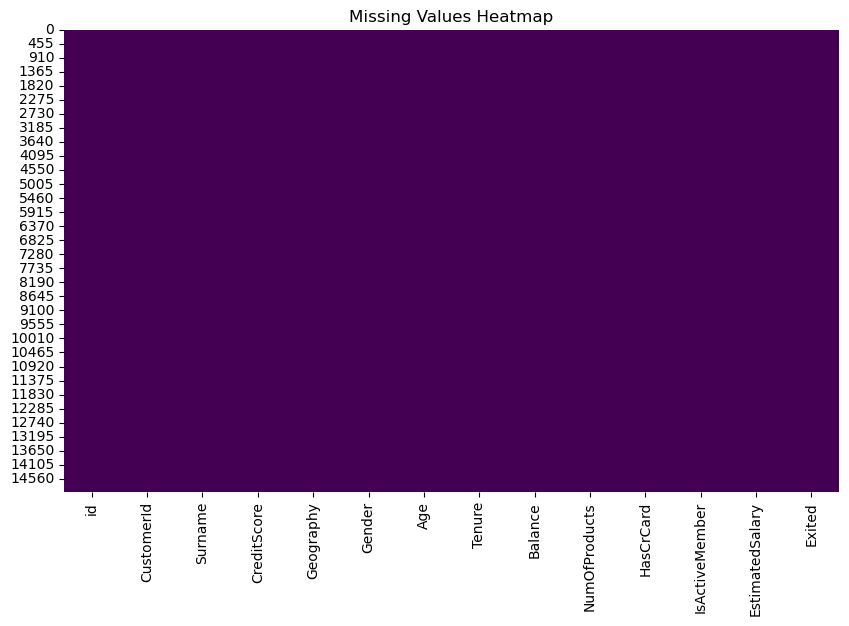

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [72]:
plt.figure(figsize=(10,6))
sns.heatmap(train_data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

print(train_data.isnull().sum().sort_values(ascending=False))

In [73]:
numeric_columns = train_data.select_dtypes(include='number').columns.tolist()

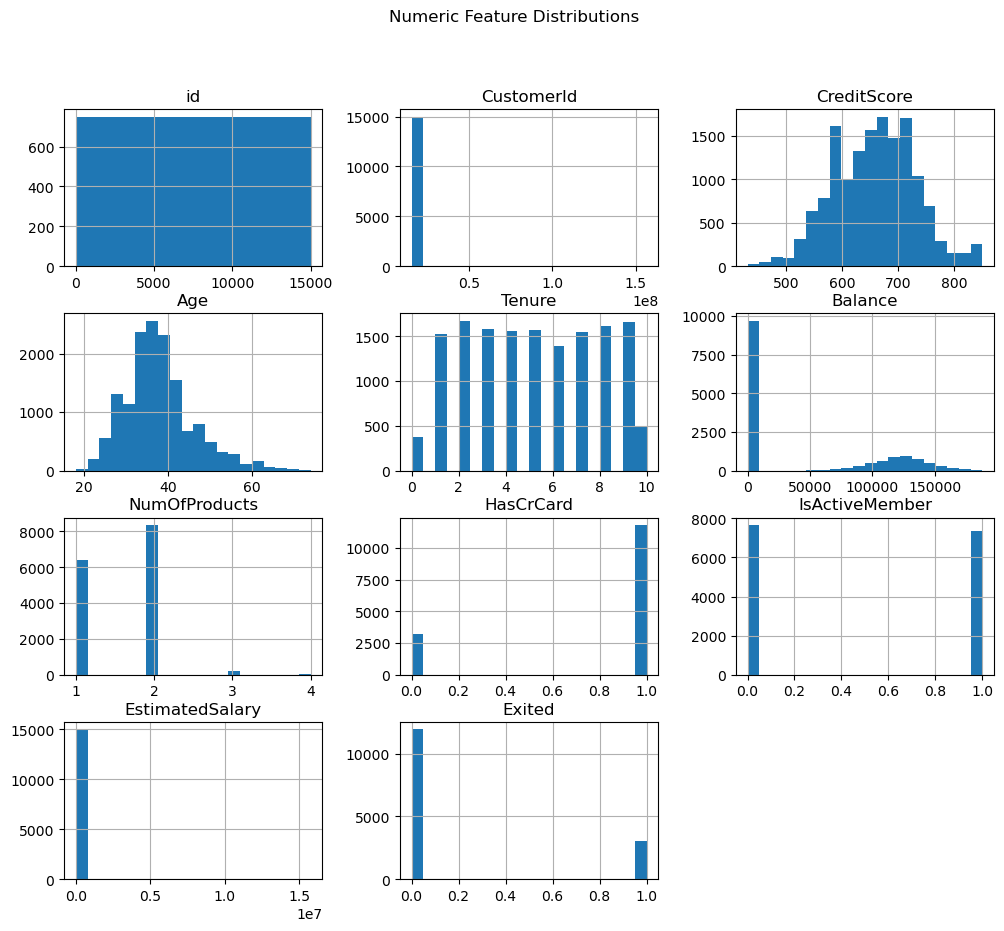

In [74]:
# Checking Skewness
train_data[numeric_columns].hist(bins=20, figsize=(12,10))
plt.suptitle('Numeric Feature Distributions')
plt.show()

In [75]:
categorical_columns = train_data.select_dtypes(include=['object', 'category']).columns.tolist()

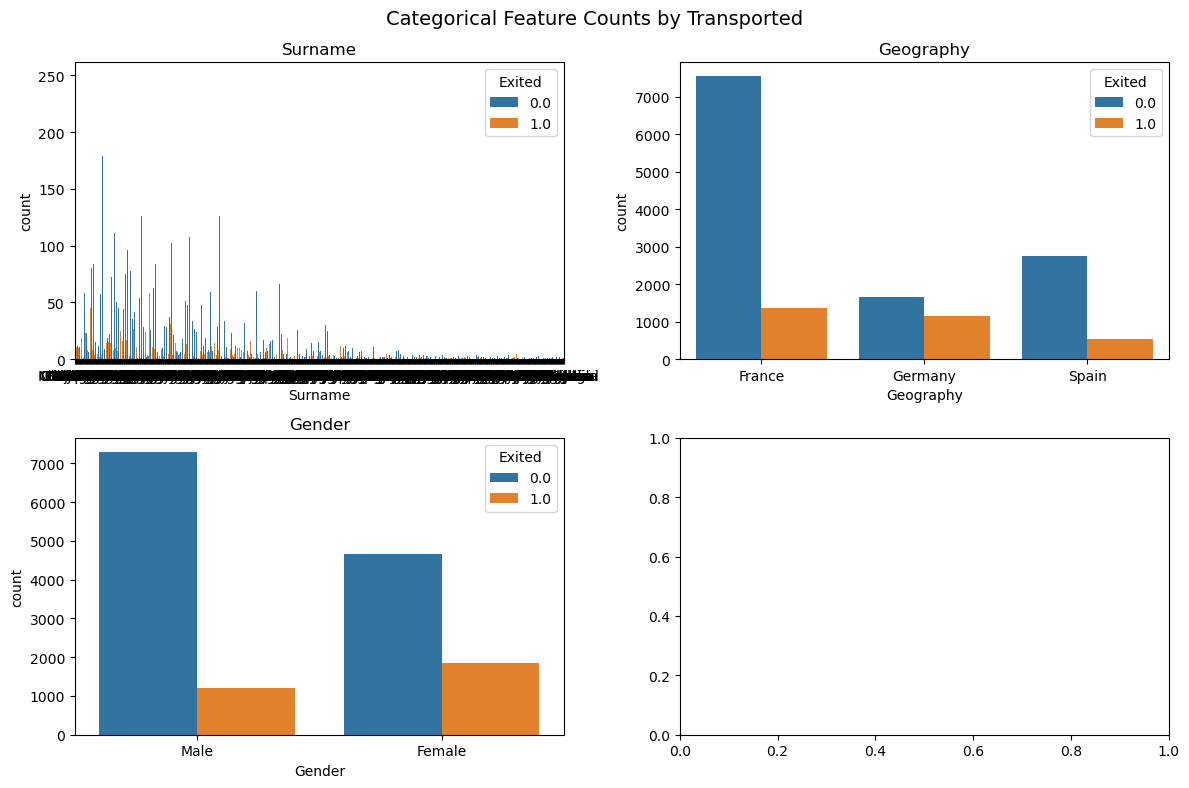

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(categorical_columns):
    sns.countplot(
        data=train_data,
        x=col,
        hue='Exited',
        ax=axes[i // 2, i % 2]
    )
    axes[i // 2, i % 2].set_title(col)

plt.suptitle('Categorical Feature Counts by Transported', fontsize=14)
plt.tight_layout()
plt.show()

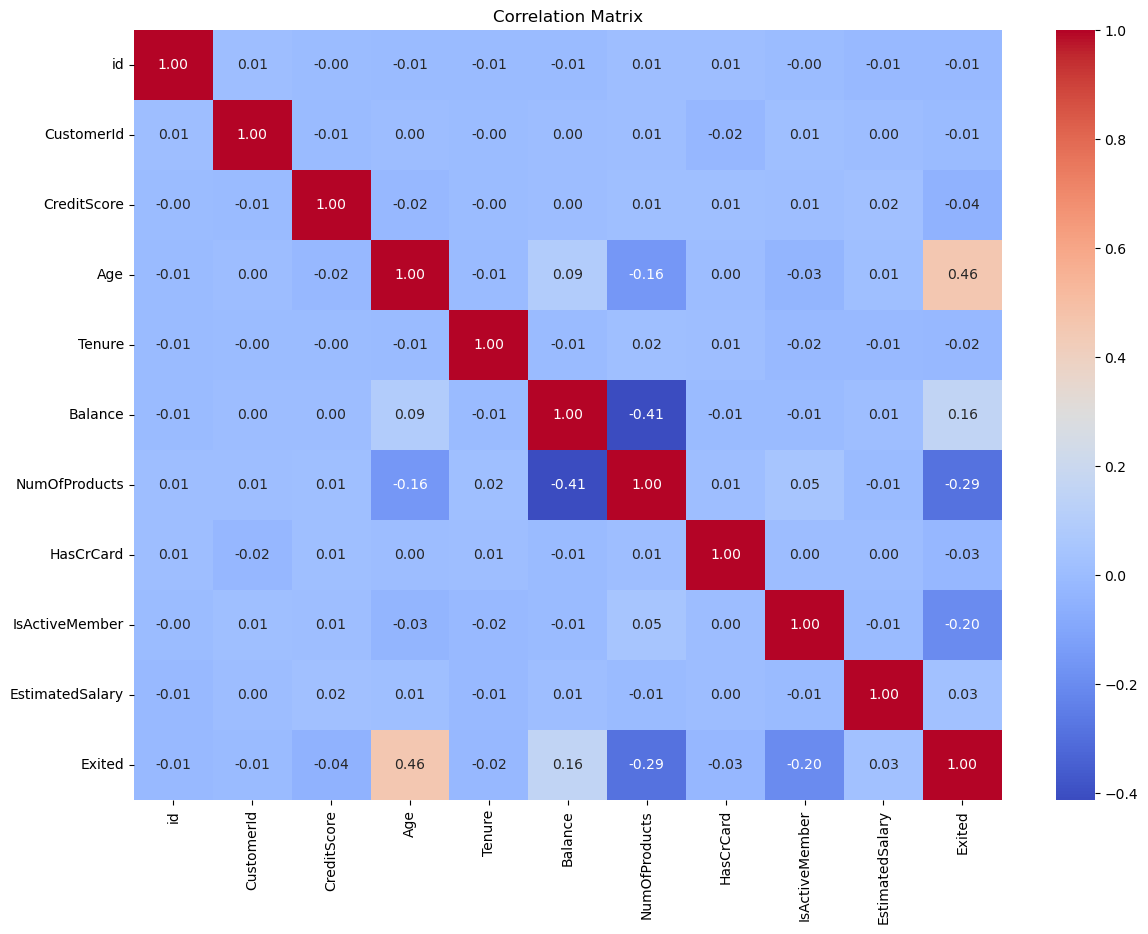

In [77]:
plt.figure(figsize=(14, 10))

corr = train_data[numeric_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Correlation Matrix')
plt.show()

## Feature Engineering

In [78]:
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_columns = ['Geography', 'Gender']

In [ ]:
class ChurnPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_columns, categorical_columns):
        self.numeric_columns = numeric_columns
        self.categorical_columns = categorical_columns
        
    def fit(self, X, y=None):
        self.num_pipeline = Pipeline([('scaler', StandardScaler())])
        self.cat_pipeline = Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
        
        self.numeric_columns_ = [c for c in self.numeric_columns if c in X.columns]
        self.categorical_columns_ = [c for c in self.categorical_columns if c in X.columns]
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', self.num_pipeline, self.numeric_columns_),
                ('cat', self.cat_pipeline, self.categorical_columns_)
            ],
            remainder='drop'
        )
        self.preprocessor.fit(X)
        return self
    
    def transform(self, X):
        return self.preprocessor.transform(X)

In [ ]:
X = train_data.drop(['Exited', 'id', 'CustomerId', 'Surname'], axis=1)
y = train_data['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [81]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((12000, 10), (12000,), (3000, 10), (3000,))

In [82]:
print(y_train.value_counts())

0.0    9555
1.0    2445
Name: Exited, dtype: int64


In [83]:
print(y_train_balanced.value_counts())

0.0    9555
1.0    9555
Name: Exited, dtype: int64


## Model

In [ ]:
pipeline = ImbPipeline(steps=[
    ('preprocessor',
        ChurnPreprocessor(
            numeric_columns=numeric_columns,
            categorical_columns=categorical_columns
        )
    ),
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    ('model',
        XGBClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        )
    )
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("----------------------------------------------------------")
print("XGBoost Classifier with SMOTE")
print("----------------------------------------------------------")
print(classification_report(y_test, y_pred))
print("----------------------------------------------------------")
print(f"Accuracy: {accuracy:.4f}")
print("----------------------------------------------------------")

----------------------------------------------------------
XGBoost Classifier with SMOTE
----------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.92      2389
         1.0       0.69      0.76      0.72       611

    accuracy                           0.88      3000
   macro avg       0.81      0.84      0.82      3000
weighted avg       0.89      0.88      0.88      3000

----------------------------------------------------------
Accuracy: 0.8813
----------------------------------------------------------


In [85]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')
print(f"Cross-Validation F1-Macro: {cv_scores.mean():.4f}")

Cross-Validation F1-Macro: 0.8193


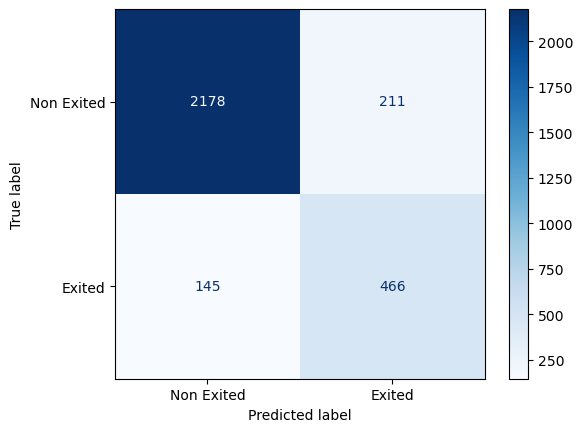

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non Exited', 'Exited'])
disp.plot(cmap='Blues')

In [ ]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")

print("\nFull Confusion Matrix:")
print(cm)


Confusion Matrix Breakdown:
True Negatives (TN): 2178
False Positives (FP): 211
False Negatives (FN): 145
True Positives (TP): 466

Full Confusion Matrix:
[[2178  211]
 [ 145  466]]


## Final Submission

In [ ]:
train_data = pd.read_csv('C:/Temp/PredictingCustomerChurn/train.csv')

numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_columns = ['Geography', 'Gender']

X_full = train_data.drop(['Exited', 'id', 'CustomerId', 'Surname'], axis=1)
y_full = train_data['Exited']

pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', ChurnPreprocessor(numeric_columns, categorical_columns)),
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    ('model', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                            objective='binary:logistic', eval_metric='logloss',
                            random_state=42, n_jobs=-1))
])

pipeline_smote.fit(X_full, y_full)

test_data = pd.read_csv('C:/Temp/PredictingCustomerChurn/test.csv')

test_ids = test_data['id']
test_features = test_data.drop(['id', 'CustomerId', 'Surname'], axis=1)

y_proba = pipeline_smote.predict_proba(test_features)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'Exited': y_proba
})

submission.to_csv('submission.csv', index=False)

      id    Exited
0  15000  0.039125
1  15001  0.005433
2  15002  0.034671
